# #LiBRARY IMPORTS 

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
tf.keras.utils.set_random_seed(42)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,Dropout


# # TASK 1.1: Load and Explore

In [30]:
# LOAD THE DATASET
df=pd.read_csv("/kaggle/input/datasets/rabieelkharoua/students-performance-dataset/Student_performance_data _.csv")

display(df.head())
print("Data Set Shape: ",df.shape)

print("\nData Set Types: ",df.dtypes)

# CHECK IF THERE ANY MISSING VALUE
print("\nMissing Values: ",df.isnull().sum())

# CHECK CLASS BALANCE
print(df["GradeClass"].value_counts())

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


Data Set Shape:  (2392, 15)

Data Set Types:  StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

Missing Values:  StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64
GradeClass
4.0    1211
3.0     414
2.0     391
1.0     269
0.0     107
Name: count, dtype: int64


# # TASK 1.2:Prepare the Data 

In [31]:
# SELECT THE 5 IMPORTANT FEATURES AND THE TARGET
X=df[["GPA","StudyTimeWeekly","Tutoring","Absences"]]
y=df["GradeClass"]

# Split THE DATA 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:",X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1913, 4)
X_test: (479, 4)
y_train: (1913,)
y_test: (479,)


In [32]:
# SCALE THE FEATURES
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# # TASK 1.3: Train and Compare Models 

I saw this video and understood how XGBOOST works:
https://youtu.be/YgUcwTAmgpc?si=dZ3i3muJ-4b-5eJw

In [33]:
xgb = xgb.XGBClassifier(n_estimators=500,max_depth=6,
                     learning_rate=0.05,random_state=42,
                     eval_metric="mlogloss")


rf = RandomForestClassifier(n_estimators=300,max_depth=15,
                          random_state=42)


dt = DecisionTreeClassifier(max_depth=10,min_samples_split=10,
                          random_state=42)

In [34]:
#FiT THE MODELS
xgb.fit(X_train_scaled,y_train)

rf.fit(X_train_scaled,y_train)

dt.fit(X_train_scaled,y_train)

DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)

In [35]:
# PREDiCT
xgb_pred=xgb.predict(X_test_scaled)

rf_pred=rf.predict(X_test_scaled)

dt_pred=dt.predict(X_test_scaled)

# Models Report

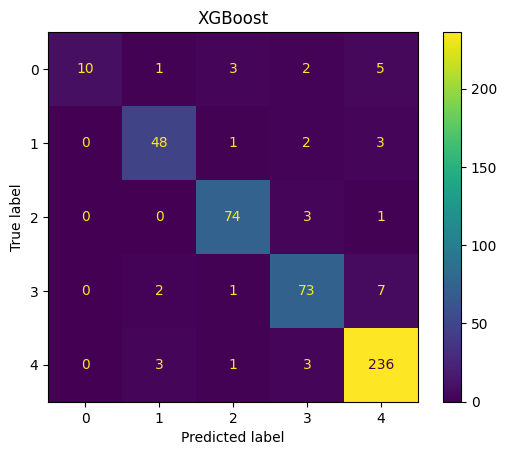

In [36]:

xgb_acc=accuracy_score(y_test,xgb_pred)

xgb_prec=precision_score(y_test,xgb_pred,average="weighted")

xgb_f1=f1_score(y_test,xgb_pred,average="weighted")

xgb_rec=recall_score(y_test,xgb_pred,average="weighted")

xgb_cm=confusion_matrix(y_test,xgb_pred)

ConfusionMatrixDisplay(confusion_matrix=xgb_cm).plot()
plt.title("XGBoost")
plt.show()

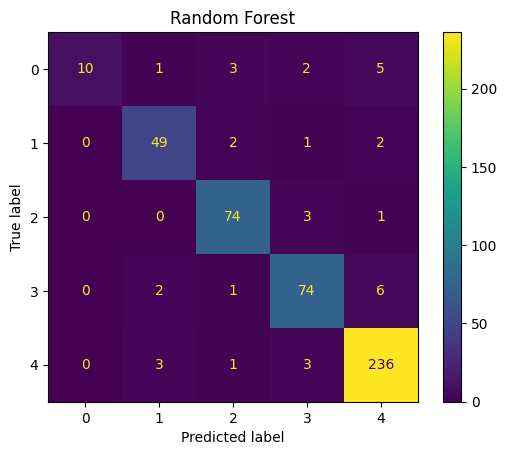

In [37]:
rf_acc=accuracy_score(y_test,rf_pred)

rf_prec=precision_score(y_test,rf_pred,average="weighted")

rf_f1=f1_score(y_test,rf_pred,average="weighted")

rf_rec=recall_score(y_test,rf_pred,average="weighted")

rf_cm=confusion_matrix(y_test,rf_pred)

ConfusionMatrixDisplay(confusion_matrix=rf_cm).plot()
plt.title("Random Forest")
plt.show()

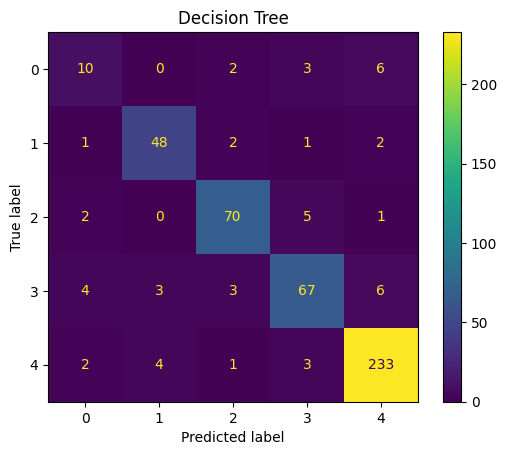

In [38]:
dt_acc=accuracy_score(y_test,dt_pred)

dt_prec=precision_score(y_test,dt_pred,average="weighted")

dt_f1=f1_score(y_test,dt_pred,average="weighted")

dt_rec=recall_score(y_test,dt_pred,average="weighted")

dt_cm=confusion_matrix(y_test,dt_pred)

ConfusionMatrixDisplay(confusion_matrix=dt_cm).plot()
plt.title("Decision Tree")
plt.show()

In [39]:
result=pd.DataFrame({
    "Model":["XGboost","Random Forest","Decision Tree"],

    "Accuracy":[xgb_acc,rf_acc,dt_acc],

    "Precision":[xgb_prec,rf_prec,dt_prec],

    "F1":[xgb_f1,rf_f1,dt_f1],

    "Recall":[xgb_rec,rf_rec,dt_rec]
})
print(result)

           Model  Accuracy  Precision        F1    Recall
0        XGboost  0.920668   0.922174  0.917162  0.920668
1  Random Forest  0.924843   0.926431  0.921402  0.924843
2  Decision Tree  0.893528   0.891179  0.892153  0.893528


In [40]:
best_model=result.sort_values(by="F1",ascending=False)
print(best_model)

           Model  Accuracy  Precision        F1    Recall
1  Random Forest  0.924843   0.926431  0.921402  0.924843
0        XGboost  0.920668   0.922174  0.917162  0.920668
2  Decision Tree  0.893528   0.891179  0.892153  0.893528


Random Forest is the best model. It achieved the highest accuracy of 92.48% and the best F1-score of 92.14%

# #Task 2.1: Build and Train 

In [41]:

model=keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(64,activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32,activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(5,activation="softmax")
])

In [42]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0008),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,141 (43.52 KB)

 Trainable params: 11,141 (43.52 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
def plot_history(history):
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"],label="Training Loss")
    plt.plot(history.history["val_loss"],label="Validation Loss")
    plt.title("model loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True)
    plt.show

    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"],label="Training Accuracy")
    plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
    plt.title("model accuracy")
    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True)
    plt.show

In [45]:
earlystop=keras.callbacks.EarlyStopping(monitor="val_loss",
                                       patience=20,
                                       restore_best_weights=True)

Epoch 1/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5228 - loss: 1.3009 - val_accuracy: 0.6867 - val_loss: 0.8939
Epoch 2/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7013 - loss: 0.8997 - val_accuracy: 0.7781 - val_loss: 0.8064
Epoch 3/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7080 - loss: 0.8191 - val_accuracy: 0.8016 - val_loss: 0.7573
Epoch 4/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7483 - loss: 0.7742 - val_accuracy: 0.8198 - val_loss: 0.7181
Epoch 5/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7817 - loss: 0.7328 - val_accuracy: 0.8251 - val_loss: 0.6751
Epoch 6/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7617 - loss: 0.7226 - val_accuracy: 0.8616 - val_loss: 0.6494
Epoch 7/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7743 - loss: 0.7244 - val_accuracy: 0.8616 - val_loss: 0.6206
Epoch 8/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8090 - loss: 0.6766 - val_accuracy: 0.8616 - v

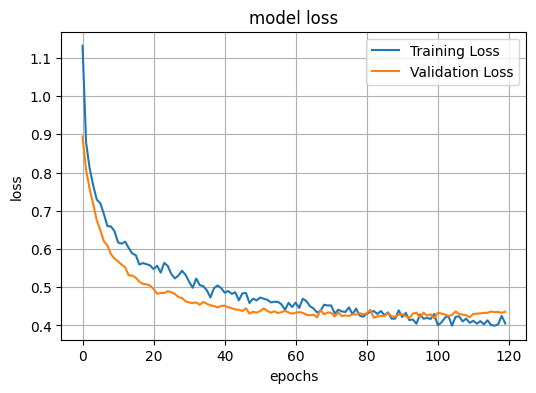

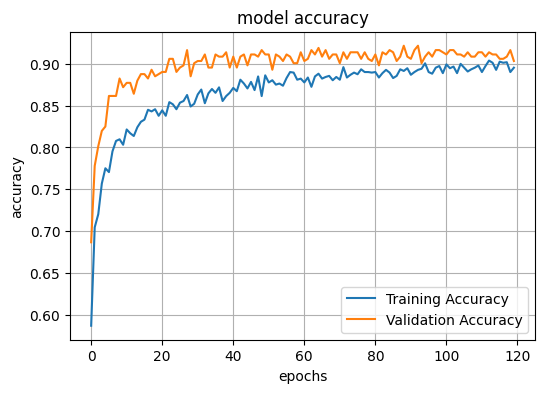

In [46]:
history=model.fit(
    X_train_scaled,y_train,
    epochs=150,batch_size=16,
    validation_split=0.2,
    callbacks=[earlystop]
)

plot_history(history)

# #Task 2.2: Compare with Step 1 

In [47]:
test_loss,test_acc=model.evaluate(X_test_scaled,y_test,verbose=0)
print("Test loss",test_loss)
print("Test accuracy",test_acc)

Test loss 0.46737051010131836
Test accuracy 0.9081419706344604


In [48]:
probs=model.predict(X_test_scaled)
preds=np.argmax(probs,axis=1)

metrics=pd.DataFrame({
    "Model":["Neural Network"],

    "Accuracy":[accuracy_score(y_test,preds)],

    "Precision":[precision_score(y_test,preds,average="weighted")],

    "F1":[f1_score(y_test,preds,average="weighted")],

    "Recall":[recall_score(y_test,preds,average="weighted")]
})

final=pd.concat([result,metrics],ignore_index=True)
print(final)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
            Model  Accuracy  Precision        F1    Recall
0         XGboost  0.920668   0.922174  0.917162  0.920668
1   Random Forest  0.924843   0.926431  0.921402  0.924843
2   Decision Tree  0.893528   0.891179  0.892153  0.893528
3  Neural Network  0.908142   0.910356  0.903678  0.908142


The neural network was not better than Random Forest and XGBoost, but it performed better than the decision tree. It achieved an accuracy of 90.81%, while Random Forest reached a higher accuracy of 92.48%. This is because tree models like Random Forest are usually stronger with tabular data than neural networks.